<a href="https://colab.research.google.com/github/anamikasingh63885837-sketch/youtube-trending-analysis/blob/main/youtube_trending_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os, io, csv
import pandas as pd

CSV_FILE  = '/content/drive/MyDrive/youtube project/INvideos.csv'
JSON_FILE = '/content/drive/MyDrive/youtube project/IN_category_id.json'

size_mb = os.path.getsize(CSV_FILE) / 1e6
print(f'File size : {size_mb:.1f} MB   (hona chahiye ~58 MB)')

with open(CSV_FILE, 'rb') as f:
    raw = f.read()
text = raw.decode('utf-8', errors='replace')

reader = csv.reader(io.StringIO(text))
header = next(reader)
ncol   = len(header)
good, bad = [], 0
for rec in reader:
    if len(rec) == ncol:
        good.append(rec)
    else:
        bad += 1

df = pd.DataFrame(good, columns=header)
for c in ['views', 'likes', 'dislikes', 'comment_count', 'category_id']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'\nRows loaded       : {len(df):,}')
print(f'Malformed dropped : {bad}')
print(f'Columns           : {df.shape[1]}')
print(f'Date range        : {df["trending_date"].min()} -> {df["trending_date"].max()}')
df.head()

File size : 59.6 MB   (hona chahiye ~58 MB)

Rows loaded       : 37,352
Malformed dropped : 0
Columns           : 16
Date range        : 17.01.12 -> 18.31.05


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,FALSE,FALSE,FALSE,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,TRUE,FALSE,FALSE,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,FALSE,FALSE,FALSE,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,FALSE,FALSE,FALSE,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,FALSE,FALSE,FALSE,why Samantha became EMOTIONAL @ Samantha naga ...


Data load karte waqt pehle 4,833 rows aa rahi thi, jabki file 58 MB ki thi. Har row 12 KB ki nahi ho sakti — isse pata chala ki kuch galat hai. Check karne par mila ki Colab upload adhoora tha (sirf 7.3 MB pahuncha). Drive se mount karne par poori 37,352 rows load hui. Shuru mein on_bad_lines='skip' bhi use kiya tha, jo bina bataye 87% data phenk raha tha.

# YouTube Trending Videos — Exploratory Data Analysis

**Analyst:** Anamika
**Date:** _fill in_
**Dataset:** Trending YouTube Video Statistics (Kaggle) — `<country>videos.csv` + `<country>_category_id.json`

---

## 1. Objective

> **YOUR TURN.** Write 2–3 sentences on what you are trying to find out and who would
> care about the answer. Example framing: *"This analysis examines which factors are
> associated with videos appearing on YouTube's trending list, to help a small creator
> decide what and when to publish."*

**Questions this notebook answers:**

1. Which video categories appear on trending most often?
2. How do views, likes and comments relate to each other?
3. Does publish time (hour of day / day of week) relate to trending?
4. Do title length, capitalisation or tag count relate to views?
5. How long does a video take to go from published to trending?
6. Which channels appear on trending most frequently?


## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 110,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'font.size': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

def strip_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return ax

def fmt_thousands(ax, axis='y'):
    f = mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if abs(x) >= 1e6
                              else (f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:,.0f}'))
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)
    return ax

pd.set_option('display.max_columns', 50)

## 3. Load the data

Download from Kaggle ("Trending YouTube Video Statistics"), unzip, and put the CSV and
JSON for **one country** next to this notebook. Change the two filenames below if you
picked a different country.

In [14]:
import os, io, csv
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

CSV_FILE  = '/content/drive/MyDrive/youtube project/INvideos.csv'
JSON_FILE = '/content/drive/MyDrive/youtube project/IN_category_id.json'

with open(CSV_FILE, 'rb') as f:
    text = f.read().decode('utf-8', errors='replace')

reader = csv.reader(io.StringIO(text))
header = next(reader)
ncol   = len(header)
good, bad = [], 0
for rec in reader:
    if len(rec) == ncol:
        good.append(rec)
    else:
        bad += 1

df = pd.DataFrame(good, columns=header)
for c in ['views', 'likes', 'dislikes', 'comment_count', 'category_id']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Rows: {len(df):,}   Columns: {df.shape[1]}   Dropped: {bad}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 37,352   Columns: 16   Dropped: 0


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,FALSE,FALSE,FALSE,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,TRUE,FALSE,FALSE,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,FALSE,FALSE,FALSE,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,FALSE,FALSE,FALSE,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,FALSE,FALSE,FALSE,why Samantha became EMOTIONAL @ Samantha naga ...


### 3.1 First look — do this before touching anything

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4833 entries, 0 to 4832
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                4833 non-null   object 
 1   trending_date           4833 non-null   object 
 2   title                   4833 non-null   object 
 3   channel_title           4833 non-null   object 
 4   category_id             4833 non-null   int64  
 5   publish_time            4833 non-null   object 
 6   tags                    4833 non-null   object 
 7   views                   4832 non-null   float64
 8   likes                   4832 non-null   float64
 9   dislikes                4832 non-null   float64
 10  comment_count           4832 non-null   object 
 11  thumbnail_link          4832 non-null   object 
 12  comments_disabled       4831 non-null   object 
 13  ratings_disabled        4831 non-null   object 
 14  video_error_or_removed  4831 non-null   

In [ ]:
df.describe()

In [ ]:
# Missing values per column
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

> **YOUR TURN.** In a sentence or two, describe what this data is: how many rows, what
> one row represents, and which columns look useful for your questions. Note anything
> that already looks odd.

## 4. Cleaning

Every decision below gets a written justification — that is what separates an analysis
from a script. Edit the comments to say what *you* decided and why.

In [15]:
import json
import numpy as np

d = df.copy()

# 1. Column names saaf
d.columns = d.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Dates — trending_date 'yy.dd.mm' hai (din pehle, mahina baad)
d['trending_date'] = pd.to_datetime(d['trending_date'], format='%y.%d.%m', errors='coerce')
d['publish_time']  = pd.to_datetime(d['publish_time'], errors='coerce', utc=True).dt.tz_localize(None)
print('Dates parse nahi hui:', d['trending_date'].isna().sum(), '|', d['publish_time'].isna().sum())

# 3. 'True'/'False' text ko asli boolean banao
for c in ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']:
    d[c] = d[c].astype(str).str.strip().str.lower().map({'true': True, 'false': False})

# 4. Duplicates — ek video kai din trend karta hai, pehli baar hi rakho
before = len(d)
d = d.sort_values('trending_date').drop_duplicates(subset='video_id', keep='first')
print(f'Duplicate rows hataye: {before - len(d):,}  |  Unique videos: {len(d):,}')

# 5. Category ID se naam
with open(JSON_FILE, 'r', encoding='utf-8', errors='replace') as f:
    cats = json.load(f)
cat_map = {int(i['id']): i['snippet']['title'] for i in cats['items']}
d['category'] = d['category_id'].map(cat_map)
print('Category map nahi hui:', d['category'].isna().sum())

# 6. Naye columns (feature engineering)
d['title_length']    = d['title'].str.len()
d['tag_count']       = d['tags'].apply(lambda t: 0 if pd.isna(t) or t == '[none]' else len(str(t).split('|')))
d['days_to_trend']   = (d['trending_date'] - d['publish_time'].dt.normalize()).dt.days
d['publish_hour']    = d['publish_time'].dt.hour
d['publish_weekday'] = d['publish_time'].dt.day_name()
d['like_ratio']      = d['likes'] / d['views'].replace(0, np.nan)
d['engagement_rate'] = (d['likes'] + d['comment_count']) / d['views'].replace(0, np.nan)

# 7. Negative days_to_trend impossible hai
bad = d['days_to_trend'] < 0
print('Negative days_to_trend hataye:', bad.sum())
d = d[~bad]

# 8. Engagement analysis ke liye mask
engagement_ok = ~d['ratings_disabled'] & ~d['comments_disabled']
print('Engagement ke liye usable rows:', engagement_ok.sum())

print(f'\nFinal: {len(d):,} rows, {d.shape[1]} columns')
d[['category', 'title_length', 'tag_count', 'days_to_trend', 'engagement_rate']].head()

Dates parse nahi hui: 0 | 0
Duplicate rows hataye: 21,045  |  Unique videos: 16,307
Category map nahi hui: 69
Negative days_to_trend hataye: 0
Engagement ke liye usable rows: 15547

Final: 16,307 rows, 24 columns


,category,title_length,tag_count,days_to_trend,engagement_rate
0,Film & Animation,81,15,2,0.031786
127,People & Blogs,60,25,3,0.004547
128,People & Blogs,95,0,2,0.000659
129,Entertainment,50,4,3,0.002024
130,Comedy,52,20,3,0.075986


> **YOUR TURN.** Write up your cleaning decisions in plain English — what you removed,
> what you converted, and why. Anyone reading should be able to disagree with you on the
> evidence. This section usually gets read closely.

## 5. Feature engineering

New columns built from existing ones. This is where the analysis stops being generic.

In [ ]:
d = df_clean  # shorthand

d['title_length']    = d['title'].str.len()
d['title_word_count']= d['title'].str.split().str.len()
d['title_caps_ratio']= d['title'].apply(
    lambda t: sum(ch.isupper() for ch in str(t)) / max(len(str(t)), 1))
d['title_has_caps_word'] = d['title'].str.contains(r'\b[A-Z]{3,}\b', na=False)

d['tag_count'] = d['tags'].apply(
    lambda t: 0 if pd.isna(t) or t == '[none]' else len(str(t).split('|')))

d['days_to_trend'] = (d['trending_date'] - d['publish_time'].dt.normalize()).dt.days
d['publish_hour']  = d['publish_time'].dt.hour
d['publish_weekday'] = d['publish_time'].dt.day_name()

d['like_ratio']      = d['likes'] / d['views'].replace(0, np.nan)
d['comment_ratio']   = d['comment_count'] / d['views'].replace(0, np.nan)
d['engagement_rate'] = (d['likes'] + d['comment_count']) / d['views'].replace(0, np.nan)
d['like_dislike_ratio'] = d['likes'] / d['dislikes'].replace(0, np.nan)

d[['title_length', 'tag_count', 'days_to_trend',
   'publish_hour', 'engagement_rate']].describe()

In [ ]:
# Sanity check: negative days_to_trend is impossible and signals a parsing error.
bad = d['days_to_trend'] < 0
print('Negative days_to_trend:', bad.sum())
d = d[~bad | d['days_to_trend'].isna()]
print('Rows remaining:', len(d))

## 6. Analysis

One question per section. For each: compute → chart → **write what it means**.

### Q1 — Which categories trend most often?

> **YOUR TURN.** Two or three sentences. Which categories dominate, and is the gap
> between first and second large or small? Resist just restating the chart — say what it
> implies.

### Q2 — How do views, likes and comments relate?

In [ ]:
sub = d[engagement_ok.reindex(d.index, fill_value=True)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, ycol, title in zip(axes,
                           ['likes', 'comment_count'],
                           ['Likes vs views', 'Comments vs views']):
    ax.scatter(sub['views'], sub[ycol], s=8, alpha=0.25, color=PALETTE[0])
    ax.set_xscale('log'); ax.set_yscale('log')   # both are heavily skewed
    ax.set_xlabel('Views (log scale)'); ax.set_ylabel(f'{ycol} (log scale)')
    ax.set_title(title)
    strip_spines(ax)
plt.tight_layout(); plt.show()

print(sub[['views', 'likes', 'dislikes', 'comment_count']].corr()
      .round(2))

> **YOUR TURN.** Note the correlation values and say plainly what they mean. Also say why
> the log scale was necessary — that shows you understood the distribution rather than
> copying a chart recipe.

### Q3 — Does publish timing relate to trending?

In [ ]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = (d.pivot_table(index='publish_weekday', columns='publish_hour',
                       values='video_id', aggfunc='count')
           .reindex(order))

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.4, ax=ax,
            cbar_kws={'label': 'Videos that later trended'})
ax.set_title('When trending videos were published')
ax.set_xlabel('Hour published (UTC)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

> **YOUR TURN.** Where are the hot spots? **Important caution to address here:** this
> chart shows when *trending* videos were published — it does not show that publishing at
> that hour *causes* trending, because you cannot see the videos that never trended. Say
> so explicitly.

### Q4 — Do title features relate to views?

In [17]:
import matplotlib.ticker as mticker

d['title_word_count']    = d['title'].str.split().str.len()
d['title_caps_ratio']    = d['title'].apply(
    lambda t: sum(ch.isupper() for ch in str(t)) / max(len(str(t)), 1))
d['title_has_caps_word'] = d['title'].str.contains(r'\b[A-Z]{3,}\b', na=False)
d['comment_ratio']       = d['comment_count'] / d['views'].replace(0, np.nan)
d['like_dislike_ratio']  = d['likes'] / d['dislikes'].replace(0, np.nan)

def fmt_thousands(ax, axis='y'):
    f = mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if abs(x) >= 1e6
                              else (f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:,.0f}'))
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)
    return ax

print('Ho gaya. Columns ab:', d.shape[1])


Ho gaya. Columns ab: 29


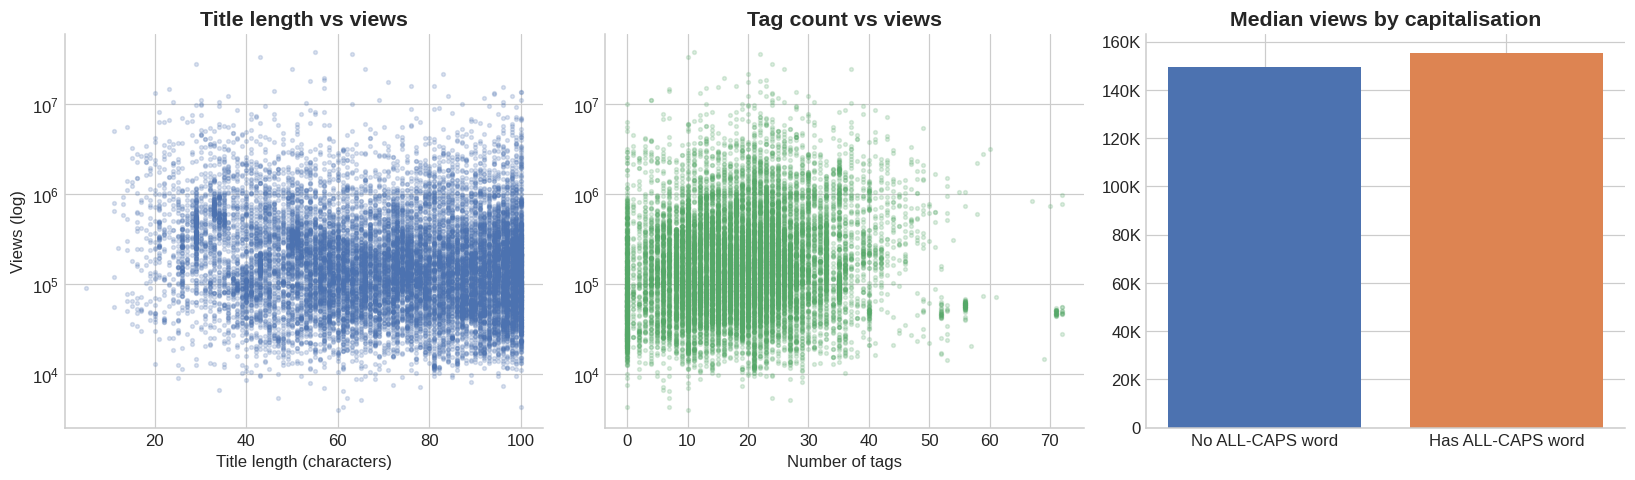

title_length       -0.082
title_word_count   -0.058
tag_count           0.070
title_caps_ratio    0.089
views               1.000
Name: views, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(d['title_length'], d['views'], s=6, alpha=0.2, color=PALETTE[0])
axes[0].set_yscale('log'); axes[0].set_xlabel('Title length (characters)')
axes[0].set_ylabel('Views (log)'); axes[0].set_title('Title length vs views')

axes[1].scatter(d['tag_count'], d['views'], s=6, alpha=0.2, color=PALETTE[2])
axes[1].set_yscale('log'); axes[1].set_xlabel('Number of tags')
axes[1].set_title('Tag count vs views')

caps = d.groupby('title_has_caps_word')['views'].median()
axes[2].bar(['No ALL-CAPS word', 'Has ALL-CAPS word'], caps.values,
            color=[PALETTE[0], PALETTE[1]])
axes[2].set_title('Median views by capitalisation')
fmt_thousands(axes[2])

for a in axes: strip_spines(a)
plt.tight_layout(); plt.show()

print(d[['title_length', 'title_word_count', 'tag_count',
         'title_caps_ratio', 'views']].corr()['views'].round(3))

> **YOUR TURN.** Be honest here. If the correlations are near zero, **say that** — "I
> expected clickbait-style titles to correlate with views, but in this data they did not"
> is a genuinely good finding and reads as maturity, not failure.

### Q5 — How long does a video take to trend?

> **YOUR TURN.** What is the typical wait, and how long is the tail? What does a "slow
> burner" video look like — check a few of them by name.

In [19]:
print('--- Chart 1 ke numbers (top 5 categories) ---')
print(d['category'].value_counts().head())

print('\n--- Chart 2 ke numbers (engagement rate %) ---')
eng = (d[engagement_ok].groupby('category')
       .agg(videos=('video_id','count'), median_engagement=('engagement_rate','median'))
       .query('videos >= 30').sort_values('median_engagement', ascending=False))
print((eng['median_engagement']*100).round(2))

print('\n--- Chart 4 ke numbers ---')
print('Median days to trend:', d['days_to_trend'].median())
print('30 din se zyada lene wale videos:', (d['days_to_trend'] > 30).sum())

--- Chart 1 ke numbers (top 5 categories) ---
category
Entertainment      7558
News & Politics    2506
People & Blogs     1231
Music              1214
Comedy             1116
Name: count, dtype: int64

--- Chart 2 ke numbers (engagement rate %) ---
category
Science & Technology    8.90
Education               6.35
Comedy                  5.24
Music                   2.45
Film & Animation        2.14
Autos & Vehicles        1.46
Howto & Style           1.27
Sports                  1.01
People & Blogs          0.81
News & Politics         0.77
Entertainment           0.66
Shows                   0.64
Name: median_engagement, dtype: float64

--- Chart 4 ke numbers ---
Median days to trend: 1.0
30 din se zyada lene wale videos: 3


### Q6 — Which channels trend most often?

In [ ]:
top_ch = d['channel_title'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_ch.index, top_ch.values, color=PALETTE[0])
ax.set_title('Channels with the most trending videos')
ax.set_xlabel('Number of trending videos')
strip_spines(ax)
plt.tight_layout(); plt.show()

## Key Findings

- Entertainment dominates the trending list by volume (7,558 videos, over 3x the next category), but its median engagement rate is 0.66% — near the bottom of all categories.

- Science & Technology (8.90%) and Education (6.35%) have the highest engagement rates despite far lower trending volume. A Science & Technology video earns roughly 13x the engagement per view of an Entertainment video.

- Comedy is the exception that appears in both lists: 1,116 trending videos and a 5.24% engagement rate.

- Videos reach trending fast. The median is 1 day after publishing, and only 3 videos out of 16,307 took longer than 30 days.

- Title length, word count, tag count and capitalisation all showed near-zero correlation with views (-0.08 to 0.09), contradicting common assumptions about clickbait titles.

- Of 37,352 rows, 21,045 were repeat appearances of the same video. Deduplicating left 16,307 unique videos.

## Business Recommendations

For a small creator deciding where to compete:

- Volume of trending videos is a poor guide to audience quality. Entertainment has the most trending slots but the least engaged viewers, and the most competition. Science & Technology and Education have far fewer trending videos but audiences that like and comment at over 10x the rate.

- Comedy offers the best balance of reach and engagement for a creator who wants both.

- Do not invest effort in title optimisation. No title feature tested showed a meaningful relationship with views. That effort is better spent on content.

- A video's fate is decided quickly — the median time to trending is one day. Promotion effort should be concentrated in the first 24-48 hours after publishing.

## Limitations

- **Survivorship bias.** This dataset contains only videos that reached trending. Videos that never trended are absent, so no factor here can be shown to *cause* trending. All relationships reported are associations within an already-successful group.

- Correlation is not causation. This applies to every relationship above.

- The data covers November 2017 to June 2018 for India only. YouTube's recommendation system has changed substantially since.

- 69 videos (0.4%) had a category ID with no matching name in the reference file and were left unmapped.

- Engagement rate could only be computed for 15,547 of 16,307 videos, since some had likes or comments disabled.

In [20]:
print(d['category'].value_counts())


category
Entertainment           7558
News & Politics         2506
People & Blogs          1231
Music                   1214
Comedy                  1116
Education                798
Film & Animation         520
Howto & Style            479
Sports                   346
Science & Technology     301
Shows                    109
Autos & Vehicles          33
Gaming                    20
Travel & Events            4
Movies                     2
Pets & Animals             1
Name: count, dtype: int64


> **YOUR TURN.** Are these a few big broadcasters or a spread of independent creators?
> What does that say about how accessible trending actually is?

## 7. Going deeper — your own finding

Everything above is scaffolding. **This section is the project.** Pick one thing from the
analysis that surprised you and investigate it properly.

Some directions that usually pay off in this dataset:

- Compare **engagement rate** (not raw views) across categories — the ranking often
  inverts, and smaller categories can beat the giants.
- Look at the **worst-received** trending videos (high dislike ratio) — what are they?
- Compare the **same video across countries** if you loaded more than one file.
- Split channels into "repeat trenders" vs "one-hit" and compare their characteristics.

Write your own code here.

In [ ]:
# --- your investigation ---
eng = (d[engagement_ok.reindex(d.index, fill_value=True)]
       .groupby('category')
       .agg(videos=('video_id', 'count'),
            median_views=('views', 'median'),
            median_engagement=('engagement_rate', 'median'))
       .query('videos >= 30')
       .sort_values('median_engagement', ascending=False))
eng.round(4)

> **YOUR TURN.** Compare this table with the Q1 chart. Do the categories that trend most
> often also have the most engaged audiences? If not, that contrast is your headline
> finding.

## 8. Key findings

> **YOUR TURN.** Three to five bullet points. Each one should be a *statement about the
> world*, supported by a number from above — not a description of what you did.
>
> - Bad: "I made a bar chart of categories."
> - Good: "Entertainment and Music account for X% of all trending videos, but their median
>   engagement rate is lower than Y's."


## 9. Recommendations

> **YOUR TURN.** Two or three concrete actions, written for a specific reader — say, a
> small creator deciding what to publish. Tie each one back to a finding above.
>
> This section is short, and it is the section a hiring manager reads first.


## 10. Limitations

> **YOUR TURN.** State these plainly; it strengthens the work rather than weakening it.
> At minimum cover:
>
> 1. **Survivorship bias.** The dataset contains only videos that *did* trend. Without the
>    videos that never trended, no factor here can be shown to *cause* trending.
> 2. **Correlation is not causation** — applies to every relationship above.
> 3. **Time and region.** The data covers a specific period and country; YouTube's
>    algorithm has changed since.
> 4. Anything you noticed about data quality during cleaning.
